# ☕ Starbucks Customer Ordering Patterns – Exploratory Data Analysis

##  Overview

This report analyzes the **Starbucks Customer Ordering Patterns dataset** to understand customer behavior, spending patterns, ordering preferences, and satisfaction levels. The goal is to derive actionable insights for improving business strategy and customer experience.

---

##  Data Preprocessing

* Converted `order_date` to datetime format
* Converted `order_time` using `%H:%M` format

These steps enabled accurate time-based and behavioral analysis.

---

##  Customer Spending Analysis

###  Gender-Based Insights

* **Female customers** contribute the **highest total spending**

 Suggests stronger purchasing behavior and engagement among female customers.

---

###  Age Group Insights

* Customers aged **25–34** spend the most

 This segment likely represents:

* Working professionals
* Frequent consumers
* Digitally active users

---

##  Regional Analysis

* The **West region** accounts for the **highest overall spending**

 Indicates strong market performance and customer concentration in this region.

---

##  Order Channel Performance

###  Revenue by Channel

| Order Channel    | Total Revenue |
| ---------------- | ------------- |
| Mobile App       | 768,610.85    |
| Drive-Thru       | 349,392.50    |
| In-Store Cashier | 276,008.48    |
| Kiosk            | 92,665.25     |

###  Key Findings

* **Mobile App** is the **leading revenue channel** by a large margin
* **Drive-Thru** is the second most preferred channel
* **In-Store Cashier** shows moderate engagement
* **Kiosk** has the lowest usage and revenue

 **Conclusion:**
Customers strongly prefer **convenience-driven and digital ordering methods**, with mobile usage dominating.

---

##  Customer Behavior Trends

* Most orders are placed through the **Mobile App**
* Customers prefer **quick and contactless ordering experiences**
* Digital adoption is significantly higher than traditional methods

---

##  Customer Satisfaction Analysis

* Ratings **4 and 5** received the **highest number of responses**

 Indicates:

* High overall **customer satisfaction**
* Positive service experience
* Strong brand loyalty

---

##  Additional Key Findings

* **Drive-Thru channel** also contributes significantly to revenue, highlighting demand for speed and convenience
* **Kiosk usage remains low**, suggesting potential underutilization or lack of awareness
* Strong alignment between **high spending segments (25–34 age group)** and **mobile app usage trends**

---

##  Key Insights Summary

* Female customers are the **top contributors to revenue**
* Age group **25–34** drives the highest spending
* The **West region** leads in total sales
* **Mobile App dominates** ordering behavior and revenue
* **Drive-Thru remains an important secondary channel**
* **Customer satisfaction is high (ratings 4 & 5 dominate)**

---

##  Business Recommendations

1. **Strengthen Mobile App Strategy**

   * Add personalized recommendations
   * Introduce loyalty rewards and offers

2. **Target Core Customer Segment**

   * Focus marketing on **25–34 age group** and female customers

3. **Expand High-Performing Regions**

   * Replicate West region strategies in other regions

4. **Improve Low-Usage Channels**

   * Promote kiosk usage through discounts or better placement

5. **Maintain Customer Satisfaction**

   * Continue delivering consistent service quality


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import warnings
warnings.filterwarnings('ignore')

/kaggle/input/datasets/likithagedipudi/starbucks-customer-ordering-patterns/starbucks_customer_ordering_patterns.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/likithagedipudi/starbucks-customer-ordering-patterns/starbucks_customer_ordering_patterns.csv")
df.head()

,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
0,CUST_12974,ORD_00000001,2024-03-25,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,0,14.48,8.2,Refresher,False,False,4
1,CUST_08235,ORD_00000002,2025-07-18,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,3,9.52,5.4,Brewed Coffee,False,True,4
2,CUST_00393,ORD_00000003,2025-01-15,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,1,9.32,4.9,Brewed Coffee,False,False,5
3,CUST_06936,ORD_00000004,2024-07-30,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,1,9.55,3.5,Refresher,False,False,4
4,CUST_09800,ORD_00000005,2024-06-18,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,1,12.24,4.1,Frappuccino,False,False,3


In [3]:
# Change data type of date and time columns
df['order_date']= pd.to_datetime(df['order_date'])
df.head(5)
df['order_time']= pd.to_datetime(df['order_time'], format = '%H:%M')  

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   customer_id            100000 non-null  object        
 1   order_id               100000 non-null  object        
 2   order_date             100000 non-null  datetime64[ns]
 3   order_time             100000 non-null  datetime64[ns]
 4   day_of_week            100000 non-null  object        
 5   order_channel          100000 non-null  object        
 6   store_id               100000 non-null  object        
 7   store_location_type    100000 non-null  object        
 8   region                 100000 non-null  object        
 9   customer_age_group     100000 non-null  object        
 10  customer_gender        100000 non-null  object        
 11  is_rewards_member      100000 non-null  bool          
 12  cart_size              100000 non-null  int64

In [5]:
df.describe()

,order_date,order_time,cart_size,num_customizations,total_spend,fulfillment_time_min,customer_satisfaction
count,100000,100000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,2024-12-30 20:31:50.879999744,1900-01-01 12:15:18.778800128,3.741510,1.81077,14.866771,4.546080,3.687530
min,2024-01-01 00:00:00,1900-01-01 00:00:00,1.000000,0.00000,3.510000,1.000000,1.000000
25%,2024-06-30 00:00:00,1900-01-01 08:15:00,3.000000,1.00000,10.837500,3.400000,3.000000
50%,2025-01-01 00:00:00,1900-01-01 12:05:00,4.000000,2.00000,14.170000,4.400000,4.000000
75%,2025-07-02 00:00:00,1900-01-01 16:04:00,5.000000,3.00000,18.180000,5.500000,5.000000
max,2025-12-30 00:00:00,1900-01-01 23:59:00,10.000000,8.00000,40.310000,11.200000,5.000000
std,NaN,NaN,1.697817,1.46280,5.506800,1.550269,1.184123


In [6]:
df.columns

Index(['customer_id', 'order_id', 'order_date', 'order_time', 'day_of_week',
       'order_channel', 'store_id', 'store_location_type', 'region',
       'customer_age_group', 'customer_gender', 'is_rewards_member',
       'cart_size', 'num_customizations', 'total_spend',
       'fulfillment_time_min', 'drink_category', 'has_food_item',
       'order_ahead', 'customer_satisfaction'],
      dtype='object')

In [7]:
df.nunique()

customer_id               14988
order_id                 100000
order_date                  730
order_time                 1440
day_of_week                   7
order_channel                 4
store_id                    500
store_location_type           3
region                        5
customer_age_group            5
customer_gender               4
is_rewards_member             2
cart_size                    10
num_customizations            9
total_spend                3137
fulfillment_time_min        102
drink_category                6
has_food_item                 2
order_ahead                   2
customer_satisfaction         5
dtype: int64

In [8]:
# Categorising the column for making it more memory efficient
df['day_of_week'] = df['day_of_week'].astype('category')
df['store_location_type'] = df['store_location_type'].astype("category")
df['region'] = df['region'].astype("category")
df['customer_age_group'] = df['customer_age_group'].astype("category")
df['customer_gender'] = df['customer_gender'].astype("category")
df['is_rewards_member'] = df['is_rewards_member'].astype("category")
df['drink_category'] = df['drink_category'].astype("category")
df['has_food_item'] = df['has_food_item'].astype("category")
df['order_ahead'] = df['order_ahead'].astype("category")
df['order_channel'] = df['order_channel'].astype("category")


In [9]:
day_count = df['day_of_week'].value_counts()
max_day = day_count.idxmax
max_day
# MAx orderplaced was on saturday. though there is no significant difference in the order placed in weekdays

<bound method Series.idxmax of day_of_week
Sat    14443
Mon    14386
Tue    14385
Fri    14277
Thu    14214
Sun    14175
Wed    14120
Name: count, dtype: int64>

In [10]:
time_count = df['order_time'].value_counts()
max_time= time_count.idxmax
max_time
# Max Order Placed at 7:26am

<bound method Series.idxmax of order_time
1900-01-01 07:26:00    208
1900-01-01 07:02:00    194
1900-01-01 07:53:00    190
1900-01-01 07:39:00    189
1900-01-01 07:03:00    188
                      ... 
1900-01-01 03:06:00      2
1900-01-01 03:38:00      2
1900-01-01 01:21:00      1
1900-01-01 00:00:00      1
1900-01-01 03:19:00      1
Name: count, Length: 1440, dtype: int64>

In [11]:
df.columns  = df.columns.str.strip()

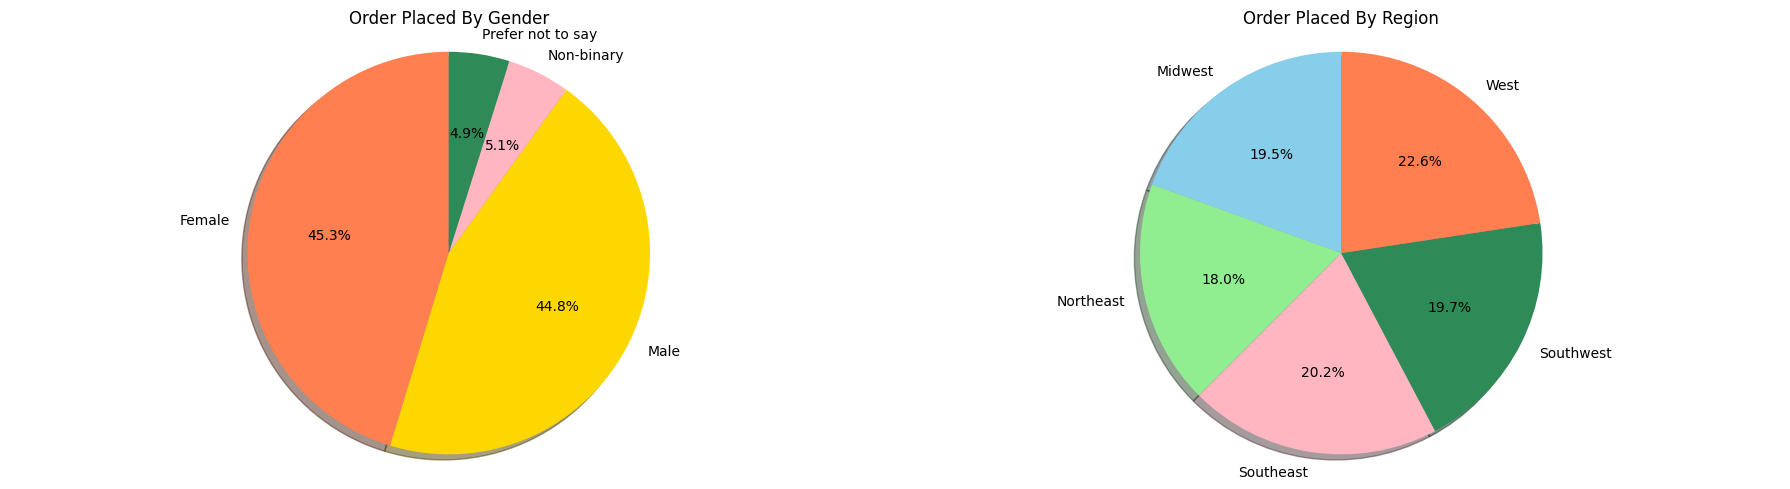

In [12]:
gender_data = df.groupby('customer_gender')['order_id'].count()
region_data = df.groupby('region')['order_id'].count()
labels = df['total_spend']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

# Plot the first pie chart on ax1
ax1.pie(gender_data, labels=gender_data.index, colors=['coral', 'gold','lightpink','seagreen',], autopct='%1.1f%%', shadow=True, startangle=90)
ax1.axis('equal') # Ensures the pie chart is drawn as a perfect circle
ax1.set_title('Order Placed By Gender') # Set a title for the first subplot

# Plot the second pie chart on ax2
ax2.pie(region_data, labels=region_data.index, colors=['skyblue','lightgreen','lightpink','seagreen','coral'], autopct='%1.1f%%', shadow=True, startangle=90)
ax2.axis('equal') # Ensures the pie chart is drawn as a perfect circle
ax2.set_title('Order Placed By Region') # Set a title for the second subplot

# Adjust layout for better spacing
plt.tight_layout()

# Display the figure with both pie charts
plt.show()
# Female are the ne who are spending the most on orders
# Most of the spending is coming from west region

Grouped Data:
customer_age_group
18-24    315228.15
25-34    462952.37
35-44    353785.90
45-54    223900.34
55+      130810.32
Name: total_spend, dtype: float64


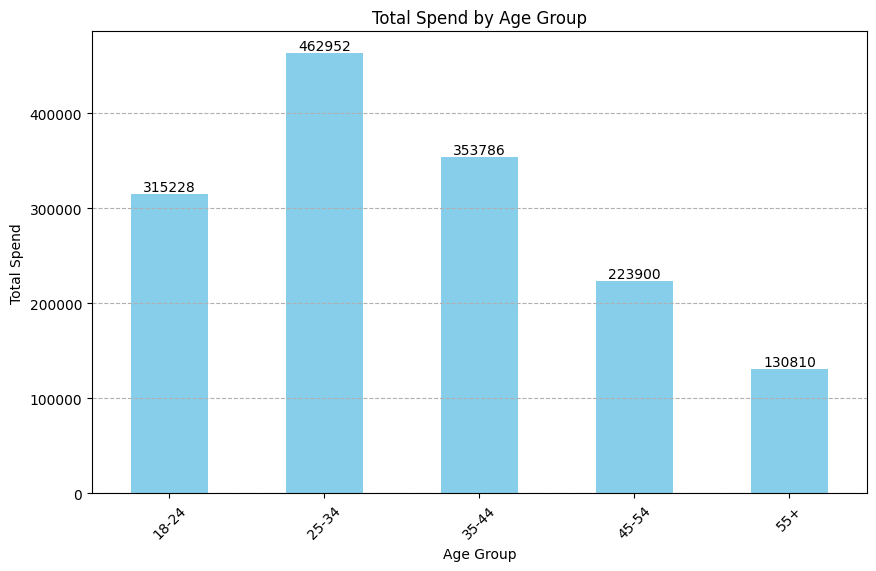

In [13]:
grouped_data = df.groupby('customer_age_group')['total_spend'].sum()
print("Grouped Data:")
print(grouped_data)

# 3. Plot the bar graph
# The index (age_group) becomes the x-axis, and the values (total_spend) become the y-axis
ax = grouped_data.plot(kind='bar', figsize=(10, 6), color='skyblue')

# 4. Customize the plot
plt.title('Total Spend by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Spend')
plt.xticks(rotation=45) # Rotate labels to prevent overlap
plt.grid(axis='y', linestyle='--')

# Optional: Add labels to the bars for clarity
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

# 5. Display the plot
plt.show()
# Customer of age group 25-34 are spending more than others 

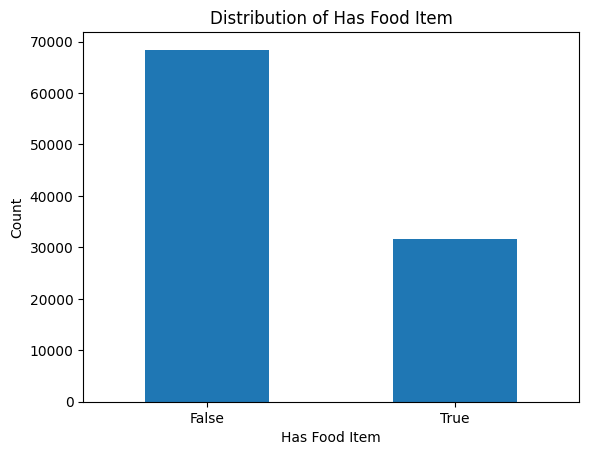

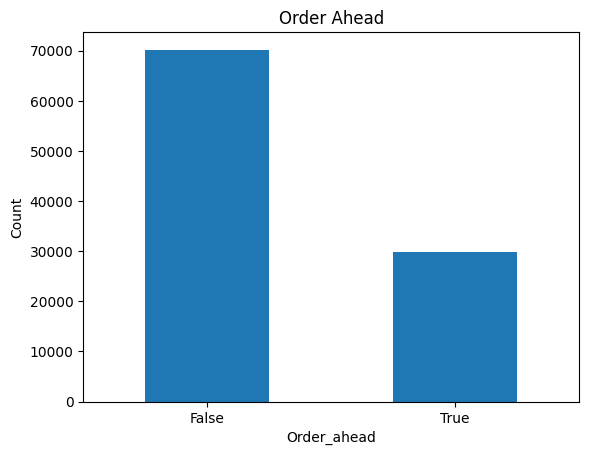

In [14]:
# Count the occurrences of True and False
count1 = df['has_food_item'].value_counts()
count2 = df['order_ahead'].value_counts()
count3 = df['is_rewards_member'].value_counts()

# Plot using pandas built-in plotting (which uses matplotlib)
count1.plot(kind='bar', rot=0)
plt.title('Distribution of Has Food Item')
plt.xlabel('Has Food Item')
plt.ylabel('Count')
plt.show()

count2.plot(kind='bar', rot=0)
plt.title('Order Ahead')
plt.xlabel('Order_ahead')
plt.ylabel('Count')
plt.show()


Grouped Data:
order_channel
Drive-Thru          349392.50
In-Store Cashier    276008.48
Kiosk                92665.25
Mobile App          768610.85
Name: total_spend, dtype: float64


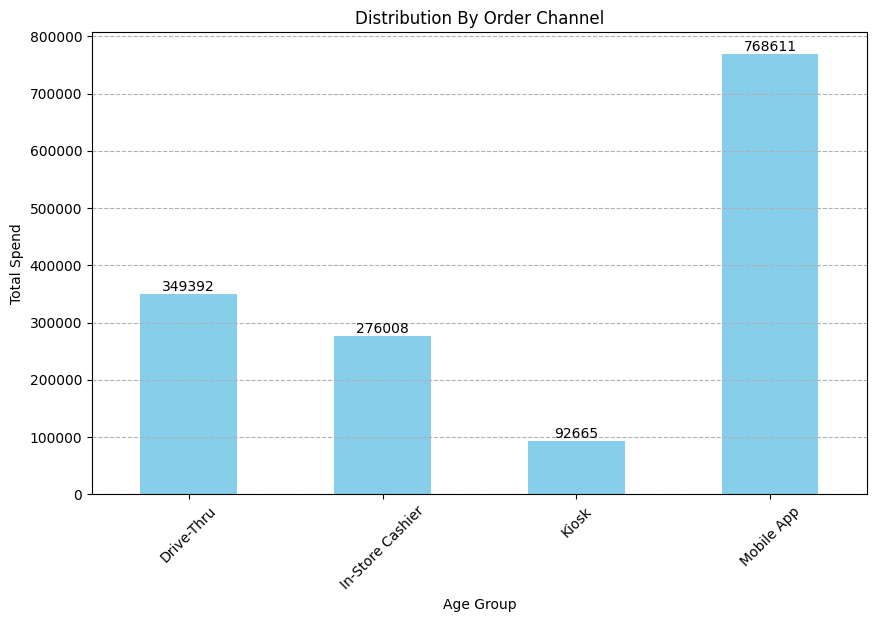

In [15]:
grouped_data = df.groupby('order_channel')['total_spend'].sum()
print("Grouped Data:")
print(grouped_data)

# 3. Plot the bar graph
# The index (age_group) becomes the x-axis, and the values (total_spend) become the y-axis
ax = grouped_data.plot(kind='bar', figsize=(10, 6), color='skyblue')

# 4. Customize the plot
plt.title('Distribution By Order Channel')
plt.xlabel('Age Group')
plt.ylabel('Total Spend')
plt.xticks(rotation=45) # Rotate labels to prevent overlap
plt.grid(axis='y', linestyle='--')

# Optional: Add labels to the bars for clarity
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
# 5. Display the plot
plt.show()
# Most of the order are made through Mobile App

In [16]:
df['customer_satisfaction'].unique()

array([4, 5, 3, 2, 1])

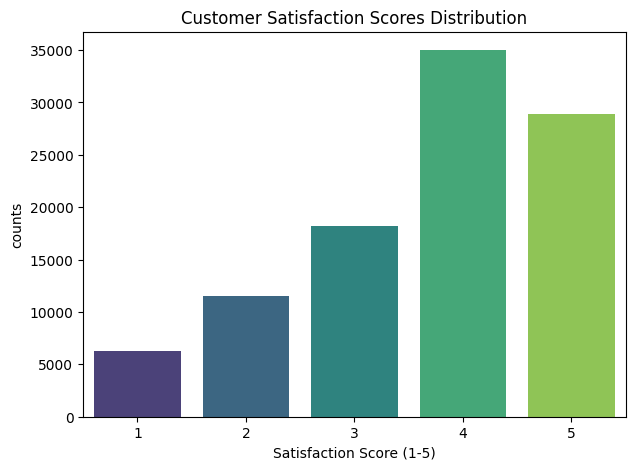

In [17]:
df['satisfaction'] = pd.Categorical(df['customer_satisfaction'], categories=[1, 2, 3, 4, 5], ordered=True)

# Create the count plot
plt.figure(figsize=(7, 5))
sns.countplot(x='satisfaction', data=df, hue = 'satisfaction', palette='viridis', legend = False) # Using 'viridis' palette for better visuals

# Add labels and a title
plt.title('Customer Satisfaction Scores Distribution')
plt.xlabel('Satisfaction Score (1-5)')
plt.ylabel('counts')

# Show the plot
plt.show()
# Score 4& 5 have received highest no of response

##  Final Conclusion

The Starbucks ecosystem is clearly shifting toward a **digital-first, convenience-driven model**, with the Mobile App emerging as the dominant channel. High customer satisfaction, strong demand from young professionals, and regional concentration of spending indicate a **mature and evolving customer base**.

By focusing on digital innovation, targeted marketing, and channel optimization, Starbucks can further enhance its competitive advantage.
